In [2]:
# %%   CELL 1: Setup
!pip -q install -U "huggingface_hub>=0.23" scikit-learn h5py >/dev/null 2>&1

import os, glob, json, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
# %%   CELL 2: Drive Connection
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# %%   CELL 3: Setting outputs' location
import os
DRIVE_OUT = "/content/drive/MyDrive/Colab Notebooks/Computer Visin/Term Project Final Delivery: Round 1/outputs"
os.makedirs(DRIVE_OUT, exist_ok=True)

In [10]:
# CELL 4: Config + HF login
from huggingface_hub import login, snapshot_download


HF_TOKEN = ""
if not HF_TOKEN:
    from getpass import getpass
    HF_TOKEN = getpass("Paste your Hugging Face read token: ").strip()
login(token=HF_TOKEN)

# Experiment configuration
CONFIG = {
    "repo_id":        "kaczmarj/camelyon16-uni",
    "data_dir":       "/content/c16_uni",
    "train_only":     True,    # download only tumor_*/normal_* slides
    "full_download":  False,

    # Model / training
    "feat_dim":       1024,    # UNI embedding dimension
    "hidden_dim":     256,
    "gat_heads":      4,
    "dropout":        0.25,
    "lr":             2e-4,
    "weight_decay":   1e-5,
    "max_epochs":     40,
    "patience":       8,       # early stopping on validation AUC
    "max_patches":    2000,    # cap patches per slide for speed/memory (None = no cap)

    # Cross-validation / reproducibility
    "n_folds":        5,
    "main_seeds":     [0, 1, 2],   # seeds for the headline comparison
    "ablation_seeds": [0],         # 1 seed for ablations

    # BA-AMIL defaults
    "knn_k":          8,
    "learned_gating": True,
    "lambda_ent":     0.01,    # attention-entropy regularization weight
    "lambda_smooth":  0.1,     # spatial smoothness penalty weight

    # FAST mode: quick smoke test to confirm everything runs end-to-end.
    "FAST":           False,
}

if CONFIG["FAST"]:
    CONFIG["n_folds"] = 3
    CONFIG["max_epochs"] = 12
    CONFIG["main_seeds"] = [0]
    CONFIG["max_patches"] = 1000
    print(">>> FAST MODE ON: results are for sanity-checking only. "
          "Set CONFIG['FAST']=False for final numbers.")

os.makedirs("/content/results", exist_ok=True)


In [12]:
# CELL 5: Download dataset
# Downloads UNI embeddings (.pt) + patch coordinates (.h5). ~11 GB (train only)
# or ~17 GB (full). This runs once per session.
if CONFIG["full_download"] or not CONFIG["train_only"]:
    allow = None
else:
    allow = ["embeddings/tumor_*", "embeddings/normal_*", "*.h5"]
snapshot_download(
    repo_id=CONFIG["repo_id"],
    repo_type="dataset",
    local_dir=CONFIG["data_dir"],
    allow_patterns=allow,
    token=HF_TOKEN,
)
print("Download complete.")

# Locate feature (.pt) and coordinate (.h5) files anywhere under data_dir.
pt_files = sorted(glob.glob(os.path.join(CONFIG["data_dir"], "**", "*.pt"), recursive=True))
h5_files = sorted(glob.glob(os.path.join(CONFIG["data_dir"], "**", "*.h5"), recursive=True))
print(f"Found {len(pt_files)} embedding files and {len(h5_files)} coordinate files.")

# Map basename (without extension) -> path, so we can pair features with coords.
def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

pt_map = {stem(p): p for p in pt_files}
h5_map = {stem(p): p for p in h5_files}

# Keep only training slides (label is unambiguous from the filename prefix).
def slide_label(name):
    n = name.lower()
    if n.startswith("tumor"):  return 1
    if n.startswith("normal"): return 0
    return None  # test_* or anything else -> skipped in this experiment

records = []
for name, ppath in pt_map.items():
    lab = slide_label(name)
    if lab is None:
        continue
    if name not in h5_map:
        continue  # need coordinates for the spatial graph
    records.append({"name": name, "feat": ppath, "coord": h5_map[name], "label": lab})

slides = pd.DataFrame(records).sort_values("name").reset_index(drop=True)
print(f"Usable training slides: {len(slides)}  "
      f"(tumor={int(slides.label.sum())}, normal={int((slides.label==0).sum())})")
assert len(slides) >= 50, (
    "Too few slides found.")

Fetching ... files: 0it [00:00, ?it/s]

Download complete.
Found 270 embedding files and 399 coordinate files.
Usable training slides: 270  (tumor=111, normal=159)


In [14]:
# CELL 6: Data loading utils
def load_coords(h5_path):
    """Return patch coordinates as a float array of shape (N, 2)."""
    with h5py.File(h5_path, "r") as f:
        if "coords" in f:
            c = f["coords"][:]
        else:
            # fall back to the first 2-D dataset found
            key = [k for k in f.keys() if f[k].ndim == 2][0]
            c = f[key][:]
    return np.asarray(c, dtype=np.float32)

def build_knn_index(coords, k):
    """k-nearest-neighbour indices (excluding self). Returns LongTensor (N, k_eff)."""
    N = coords.shape[0]
    if N <= 1:
        return torch.zeros((N, 0), dtype=torch.long)
    k_eff = min(k, N - 1)
    nn_ = NearestNeighbors(n_neighbors=k_eff + 1).fit(coords)
    _, idx = nn_.kneighbors(coords)          # (N, k_eff+1), col 0 is self
    return torch.as_tensor(idx[:, 1:], dtype=torch.long)

_SLIDE_CACHE = {}

def load_slide(rec, k, max_patches, seed=0):
    """Load one slide (cached): features (N,1024), coords (N,2), kNN index (N,k_eff)."""
    name = rec["name"]
    if name in _SLIDE_CACHE:
        feats, coords = _SLIDE_CACHE[name]
    else:
        feats = torch.load(rec["feat"], map_location="cpu")
        if isinstance(feats, dict):
            feats = feats[list(feats.keys())[0]]
        feats = torch.as_tensor(feats, dtype=torch.float32)
        coords = load_coords(rec["coord"])
        assert feats.shape[0] == coords.shape[0], (
            f"Patch count mismatch in {name}: {feats.shape[0]} feats vs {coords.shape[0]} coords")
        N = feats.shape[0]
        if max_patches is not None and N > max_patches:
            g = torch.Generator().manual_seed(seed)
            sel = torch.randperm(N, generator=g)[:max_patches]
            feats, coords = feats[sel], coords[sel.numpy()]
        _SLIDE_CACHE[name] = (feats, coords)   # cache the subsampled slide
    nbr = build_knn_index(coords, k)
    return feats, torch.as_tensor(coords), nbr

In [8]:
# CELL 7: Models
class GatedAttention(nn.Module):
    """Ilse et al. (2018) gated attention pooling. Returns (pooled, attn)."""
    def __init__(self, dim, hidden=128, dropout=0.25):
        super().__init__()
        self.V = nn.Linear(dim, hidden)
        self.U = nn.Linear(dim, hidden)
        self.w = nn.Linear(hidden, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, h):                      # h: (N, dim)
        a = torch.tanh(self.V(h)) * torch.sigmoid(self.U(h))
        a = self.w(self.drop(a)).squeeze(-1)   # (N,)
        attn = torch.softmax(a, dim=0)         # (N,)
        pooled = (attn.unsqueeze(-1) * h).sum(0)  # (dim,)
        return pooled, attn


class GATLayer(nn.Module):
    """Lightweight multi-head graph attention over a fixed-k neighbour index."""
    def __init__(self, dim, heads=4, dropout=0.25):
        super().__init__()
        assert dim % heads == 0, "hidden_dim must be divisible by gat_heads"
        self.h, self.dh = heads, dim // heads
        self.W = nn.Linear(dim, dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, self.dh))
        self.a_dst = nn.Parameter(torch.empty(heads, self.dh))
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)
        self.leaky = nn.LeakyReLU(0.2)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, nbr):                 # x:(N,dim)  nbr:(N,k)
        N = x.shape[0]
        if nbr.numel() == 0:                   # no neighbours -> return projection
            return F.elu(self.W(x))
        k = nbr.shape[1]
        Wh = self.W(x).view(N, self.h, self.dh)            # (N,H,dh)
        e_src = (Wh * self.a_src).sum(-1)                  # (N,H)
        Wh_nbr = Wh[nbr]                                   # (N,k,H,dh)
        e_dst = (Wh_nbr * self.a_dst).sum(-1)              # (N,k,H)
        e = self.leaky(e_src.unsqueeze(1) + e_dst)         # (N,k,H)
        alpha = self.drop(torch.softmax(e, dim=1))         # over k neighbours
        out = (alpha.unsqueeze(-1) * Wh_nbr).sum(1)        # (N,H,dh)
        out = out.reshape(N, self.h * self.dh)             # (N,dim)
        return F.elu(out + self.W(x))                      # residual


class ABMIL(nn.Module):
    """Baseline 1: attention-based MIL (Ilse et al., 2018)."""
    def __init__(self, cfg):
        super().__init__()
        D = cfg["hidden_dim"]
        self.fc = nn.Sequential(nn.Linear(cfg["feat_dim"], D), nn.ReLU(),
                                nn.Dropout(cfg["dropout"]))
        self.att = GatedAttention(D, dropout=cfg["dropout"])
        self.clf = nn.Linear(D, 1)

    def forward(self, feats, nbr=None):
        h = self.fc(feats)
        z, attn = self.att(h)
        return {"logit": self.clf(z).squeeze(-1), "attn": attn, "inst_loss": 0.0}


class CLAM_SB(nn.Module):
    """Baseline 2: CLAM single-branch with instance clustering (Lu et al., 2021)."""
    def __init__(self, cfg, k_sample=8):
        super().__init__()
        D = cfg["hidden_dim"]
        self.k_sample = k_sample
        self.fc = nn.Sequential(nn.Linear(cfg["feat_dim"], D), nn.ReLU(),
                                nn.Dropout(cfg["dropout"]))
        self.att = GatedAttention(D, dropout=cfg["dropout"])
        self.clf = nn.Linear(D, 1)
        self.inst = nn.Linear(D, 2)            # instance-level classifier
        self.inst_loss_fn = nn.CrossEntropyLoss()

    def _instance_eval(self, h, attn, label):
        # top-k attended = in-class (1); bottom-k = out-of-class (0)
        N = h.shape[0]
        ks = min(self.k_sample, N // 2 if N >= 2 else 1)
        if ks < 1:
            return torch.tensor(0.0, device=h.device)
        order = torch.argsort(attn, descending=True)
        top, bot = order[:ks], order[-ks:]
        idx = torch.cat([top, bot])
        targets = torch.cat([torch.ones(ks, dtype=torch.long, device=h.device),
                             torch.zeros(ks, dtype=torch.long, device=h.device)])
        logits = self.inst(h[idx])
        return self.inst_loss_fn(logits, targets)

    def forward(self, feats, nbr=None, label=None):
        h = self.fc(feats)
        z, attn = self.att(h)
        inst = self._instance_eval(h, attn, label) if label is not None else 0.0
        return {"logit": self.clf(z).squeeze(-1), "attn": attn, "inst_loss": inst}


class BA_AMIL(nn.Module):
    """Proposed: dual-stream (global attention + boundary-aware GAT) with
    learned gating, attention-entropy and spatial-smoothness regularisation."""
    def __init__(self, cfg):
        super().__init__()
        D = cfg["hidden_dim"]
        self.learned_gating = cfg["learned_gating"]
        self.fc = nn.Sequential(nn.Linear(cfg["feat_dim"], D), nn.ReLU(),
                                nn.Dropout(cfg["dropout"]))
        self.att_glob = GatedAttention(D, dropout=cfg["dropout"])     # stream A
        self.gat = GATLayer(D, heads=cfg["gat_heads"], dropout=cfg["dropout"])
        self.att_bnd = GatedAttention(D, dropout=cfg["dropout"])      # stream B
        if self.learned_gating:
            self.gate = nn.Sequential(nn.Linear(2 * D, D), nn.ReLU(),
                                      nn.Linear(D, 1))
        self.clf = nn.Linear(D, 1)

    def forward(self, feats, nbr=None, label=None):
        h = self.fc(feats)                       # (N,D)
        z_glob, a_glob = self.att_glob(h)        # global stream
        h_ctx = self.gat(h, nbr)                 # spatial context
        z_bnd, a_bnd = self.att_bnd(h_ctx)       # boundary-aware stream
        if self.learned_gating:
            g = torch.sigmoid(self.gate(torch.cat([z_glob, z_bnd], dim=-1)))  # (1,)
            z = g * z_glob + (1.0 - g) * z_bnd
        else:
            z = 0.5 * z_glob + 0.5 * z_bnd       # fixed fusion (ablation)
        return {"logit": self.clf(z).squeeze(-1), "attn": a_glob,
                "attn_bnd": a_bnd, "inst_loss": 0.0}


def build_model(name, cfg):
    if name == "ABMIL":   return ABMIL(cfg)
    if name == "CLAM_SB": return CLAM_SB(cfg)
    if name == "BA_AMIL": return BA_AMIL(cfg)
    raise ValueError(name)

In [6]:
# CELL 8: Train / eval utilities
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def attn_entropy(attn):
    """Normalised entropy of an attention vector in [0,1]. 1 = uniform."""
    a = attn.clamp_min(1e-12)
    H = -(a * a.log()).sum()
    return (H / np.log(len(a))).item() if len(a) > 1 else 0.0

def smoothness_penalty(attn, nbr):
    """Graph-Laplacian smoothness: mean squared attention diff over kNN edges."""
    if nbr.numel() == 0:
        return torch.tensor(0.0, device=attn.device)
    diff = attn.unsqueeze(1) - attn[nbr]          # (N,k)
    return (diff ** 2).mean()

def run_epoch(model, recs, cfg, train, optimizer=None, hp=None):
    """One pass over a list of slide records. Returns (mean_loss, auc, acc, f1, ent)."""
    model.train() if train else model.eval()
    hp = hp or {}
    losses, ys, ps, ents = [], [], [], []
    bce = nn.BCEWithLogitsLoss()
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for rec in recs:
            feats, _, nbr = load_slide(rec, hp.get("knn_k", cfg["knn_k"]),
                                       cfg["max_patches"], seed=0)
            feats, nbr = feats.to(DEVICE), nbr.to(DEVICE)
            y = torch.tensor(float(rec["label"]), device=DEVICE)

            out = model(feats, nbr=nbr, label=rec["label"]) \
                if isinstance(model, (CLAM_SB, BA_AMIL)) else model(feats, nbr=nbr)

            loss = bce(out["logit"], y)
            if isinstance(model, CLAM_SB):
                loss = loss + 0.3 * out["inst_loss"]      # CLAM bag/instance mix
            if isinstance(model, BA_AMIL):
                le = hp.get("lambda_ent", cfg["lambda_ent"])
                ls = hp.get("lambda_smooth", cfg["lambda_smooth"])
                a = out["attn"].clamp_min(1e-12)
                ent_term = -(a * a.log()).sum()           # penalise high entropy
                loss = loss + le * ent_term + ls * smoothness_penalty(out["attn"], nbr)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(loss.item())
            ys.append(rec["label"])
            ps.append(torch.sigmoid(out["logit"]).item())
            ents.append(attn_entropy(out["attn"].detach()))

    ys, ps = np.array(ys), np.array(ps)
    preds = (ps >= 0.5).astype(int)
    auc = roc_auc_score(ys, ps) if len(np.unique(ys)) > 1 else float("nan")
    acc = accuracy_score(ys, preds)
    f1  = f1_score(ys, preds, zero_division=0)
    return float(np.mean(losses)), auc, acc, f1, float(np.mean(ents))

def train_fold(model_name, train_recs, val_recs, cfg, seed, hp=None):
    """Train one model on one fold/seed with early stopping on val AUC."""
    set_seed(seed)
    model = build_model(model_name, cfg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                           weight_decay=cfg["weight_decay"])
    best_auc, best_state, wait = -1.0, None, 0
    for epoch in range(cfg["max_epochs"]):
        random.shuffle(train_recs)
        run_epoch(model, train_recs, cfg, train=True, optimizer=opt, hp=hp)
        _, vauc, _, _, _ = run_epoch(model, val_recs, cfg, train=False, hp=hp)
        if np.isnan(vauc): vauc = 0.0
        if vauc > best_auc:
            best_auc = vauc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    _, auc, acc, f1, ent = run_epoch(model, val_recs, cfg, train=False, hp=hp)
    return {"auc": auc, "acc": acc, "f1": f1, "entropy": ent}

def cross_validate(model_name, cfg, seeds, hp=None, tag=""):
    """Stratified k-fold CV across the given seeds. Returns a list of fold rows."""
    X = np.arange(len(slides))
    y = slides["label"].values
    rows = []
    for seed in seeds:
        skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=seed)
        for fold, (tr, va) in enumerate(skf.split(X, y)):
            tr_recs = slides.iloc[tr].to_dict("records")
            va_recs = slides.iloc[va].to_dict("records")
            res = train_fold(model_name, tr_recs, va_recs, cfg, seed, hp=hp)
            res.update({"model": model_name, "tag": tag, "seed": seed, "fold": fold})
            rows.append(res)
            print(f"  [{tag or model_name}] seed{seed} fold{fold}  "
                  f"AUC={res['auc']:.3f} ACC={res['acc']:.3f} "
                  f"F1={res['f1']:.3f} ent={res['entropy']:.3f}")
    return rows

def summarize(rows, by=("model", "tag")):
    df = pd.DataFrame(rows)
    g = df.groupby(list(by)).agg(
        AUC_mean=("auc", "mean"),  AUC_std=("auc", "std"),
        ACC_mean=("acc", "mean"),  ACC_std=("acc", "std"),
        F1_mean=("f1", "mean"),    F1_std=("f1", "std"),
        Ent_mean=("entropy", "mean")).reset_index()
    return df, g

In [36]:
# CELL 9: Headline comparison
# ABMIL vs CLAM-SB vs BA-AMIL on identical UNI features and CV splits.
all_rows = []
print("\n=== Headline comparison (ABMIL / CLAM_SB / BA_AMIL) ===")
for m in ["ABMIL", "CLAM_SB", "BA_AMIL"]:
    print(f"\n-- {m} --")
    all_rows += cross_validate(m, CONFIG, CONFIG["main_seeds"], tag=m)

main_df, main_summary = summarize(all_rows, by=("model",))
print("\n=== Summary (mean over folds x seeds) ===")
print(main_summary.to_string(index=False))
main_df.to_csv("/content/results/main_comparison_raw.csv", index=False)
main_summary.to_csv("/content/results/main_comparison_summary.csv", index=False)


=== Headline comparison (ABMIL / CLAM_SB / BA_AMIL) ===

-- ABMIL --
  [ABMIL] seed0 fold0  AUC=0.969 ACC=0.926 F1=0.909 ent=0.738
  [ABMIL] seed0 fold1  AUC=0.997 ACC=0.981 F1=0.977 ent=0.759
  [ABMIL] seed0 fold2  AUC=0.967 ACC=0.907 F1=0.872 ent=0.817
  [ABMIL] seed0 fold3  AUC=0.996 ACC=0.944 F1=0.933 ent=0.709
  [ABMIL] seed0 fold4  AUC=1.000 ACC=1.000 F1=1.000 ent=0.722
  [ABMIL] seed1 fold0  AUC=0.964 ACC=0.944 F1=0.927 ent=0.737
  [ABMIL] seed1 fold1  AUC=0.982 ACC=0.944 F1=0.927 ent=0.749
  [ABMIL] seed1 fold2  AUC=0.997 ACC=0.963 F1=0.957 ent=0.694
  [ABMIL] seed1 fold3  AUC=0.974 ACC=0.907 F1=0.872 ent=0.780
  [ABMIL] seed1 fold4  AUC=1.000 ACC=0.981 F1=0.979 ent=0.759
  [ABMIL] seed2 fold0  AUC=0.991 ACC=0.944 F1=0.930 ent=0.741
  [ABMIL] seed2 fold1  AUC=0.991 ACC=0.963 F1=0.952 ent=0.741
  [ABMIL] seed2 fold2  AUC=0.973 ACC=0.963 F1=0.955 ent=0.738
  [ABMIL] seed2 fold3  AUC=0.999 ACC=0.981 F1=0.977 ent=0.695
  [ABMIL] seed2 fold4  AUC=0.968 ACC=0.944 F1=0.930 ent=0.794


In [37]:
# CELL 10: Ablations
# All ablations vary ONE thing at a time, on BA-AMIL, using ablation_seeds.
ablation_rows = []

# (a) kNN sensitivity: k in {5, 8, 15}
print("\n=== Ablation A: kNN k in {5,8,15} ===")
for k in [5, 8, 15]:
    hp = {"knn_k": k}
    ablation_rows += cross_validate("BA_AMIL", CONFIG, CONFIG["ablation_seeds"],
                                    hp=hp, tag=f"k={k}")

# (b) learned gating vs fixed fusion
print("\n=== Ablation B: learned gating vs fixed fusion ===")
for lg in [True, False]:
    cfg2 = dict(CONFIG); cfg2["learned_gating"] = lg
    ablation_rows += cross_validate("BA_AMIL", cfg2, CONFIG["ablation_seeds"],
                                    tag=f"gating={'learned' if lg else 'fixed'}")

# (c) spatial smoothness weight: lambda_smooth in {0, 0.01, 0.1, 0.5}
print("\n=== Ablation C: spatial smoothness weight ===")
for ls in [0.0, 0.01, 0.1, 0.5]:
    hp = {"lambda_smooth": ls}
    ablation_rows += cross_validate("BA_AMIL", CONFIG, CONFIG["ablation_seeds"],
                                    hp=hp, tag=f"smooth={ls}")

# (d) attention entropy regularization: lambda_ent in {0, 0.01, 0.1}
print("\n=== Ablation D: attention entropy regularization ===")
for le in [0.0, 0.01, 0.1]:
    hp = {"lambda_ent": le}
    ablation_rows += cross_validate("BA_AMIL", CONFIG, CONFIG["ablation_seeds"],
                                    hp=hp, tag=f"ent={le}")

abl_df, abl_summary = summarize(ablation_rows, by=("tag",))
print("\n=== Ablation summary ===")
print(abl_summary.to_string(index=False))
abl_df.to_csv("/content/results/ablations_raw.csv", index=False)
abl_summary.to_csv("/content/results/ablations_summary.csv", index=False)


=== Ablation A: kNN k in {5,8,15} ===
  [k=5] seed0 fold0  AUC=0.987 ACC=0.963 F1=0.952 ent=0.414
  [k=5] seed0 fold1  AUC=1.000 ACC=0.963 F1=0.952 ent=0.589
  [k=5] seed0 fold2  AUC=0.940 ACC=0.907 F1=0.872 ent=0.875
  [k=5] seed0 fold3  AUC=1.000 ACC=0.981 F1=0.977 ent=0.234
  [k=5] seed0 fold4  AUC=1.000 ACC=1.000 F1=1.000 ent=0.730
  [k=8] seed0 fold0  AUC=0.997 ACC=0.963 F1=0.952 ent=0.336
  [k=8] seed0 fold1  AUC=1.000 ACC=1.000 F1=1.000 ent=0.693
  [k=8] seed0 fold2  AUC=0.956 ACC=0.926 F1=0.900 ent=0.655
  [k=8] seed0 fold3  AUC=1.000 ACC=0.981 F1=0.977 ent=0.308
  [k=8] seed0 fold4  AUC=1.000 ACC=1.000 F1=1.000 ent=0.730
  [k=15] seed0 fold0  AUC=0.982 ACC=0.870 F1=0.857 ent=0.604
  [k=15] seed0 fold1  AUC=1.000 ACC=1.000 F1=1.000 ent=0.391
  [k=15] seed0 fold2  AUC=0.942 ACC=0.907 F1=0.872 ent=0.871
  [k=15] seed0 fold3  AUC=0.996 ACC=0.852 F1=0.846 ent=0.616
  [k=15] seed0 fold4  AUC=1.000 ACC=1.000 F1=1.000 ent=0.728

=== Ablation B: learned gating vs fixed fusion ===
  [g

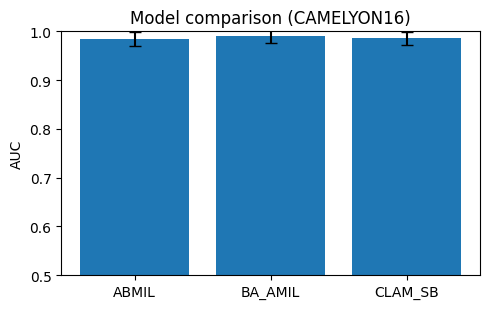

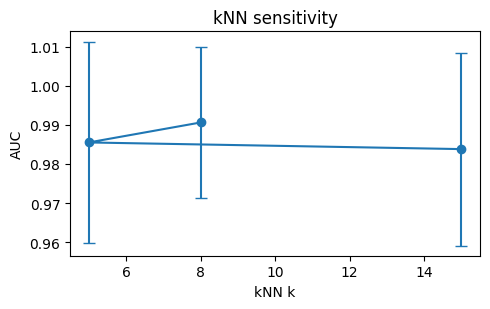

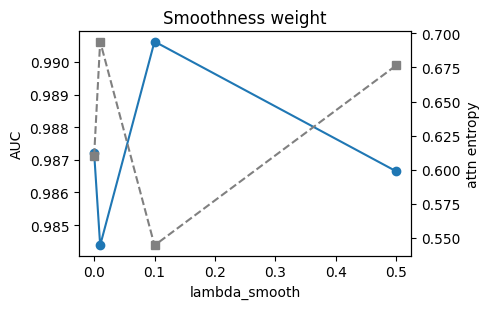


All done. Files saved in /content/results/:
   /content/results/RESULTS_BUNDLE.json
   /content/results/ablations_raw.csv
   /content/results/ablations_summary.csv
   /content/results/fig_knn_sensitivity.png
   /content/results/fig_model_comparison.png
   /content/results/fig_smoothness.png
   /content/results/main_comparison_raw.csv
   /content/results/main_comparison_summary.csv


In [38]:
# CELL 11: Save everything + figures
import matplotlib.pyplot as plt

# Bundle all numeric results into one JSON.
bundle = {
    "config": {k: v for k, v in CONFIG.items() if k != "data_dir"},
    "n_slides": int(len(slides)),
    "n_tumor": int(slides.label.sum()),
    "n_normal": int((slides.label == 0).sum()),
    "main_summary": main_summary.to_dict("records"),
    "ablation_summary": abl_summary.to_dict("records"),
}
with open("/content/results/RESULTS_BUNDLE.json", "w") as f:
    json.dump(bundle, f, indent=2)

# Figure 1: model comparison (AUC)
plt.figure(figsize=(5, 3.2))
plt.bar(main_summary["model"], main_summary["AUC_mean"],
        yerr=main_summary["AUC_std"], capsize=4)
plt.ylabel("AUC"); plt.ylim(0.5, 1.0); plt.title("Model comparison (CAMELYON16)")
plt.tight_layout(); plt.savefig("/content/results/fig_model_comparison.png", dpi=150)
plt.show()

# Figure 2: k sensitivity
ks = abl_summary[abl_summary.tag.str.startswith("k=")]
if len(ks):
    plt.figure(figsize=(5, 3.2))
    plt.errorbar([int(t.split("=")[1]) for t in ks.tag], ks["AUC_mean"],
                 yerr=ks["AUC_std"], marker="o", capsize=4)
    plt.xlabel("kNN k"); plt.ylabel("AUC"); plt.title("kNN sensitivity")
    plt.tight_layout(); plt.savefig("/content/results/fig_knn_sensitivity.png", dpi=150)
    plt.show()

# Figure 3: smoothness weight vs AUC and attention entropy
sm = abl_summary[abl_summary.tag.str.startswith("smooth=")]
if len(sm):
    xs = [float(t.split("=")[1]) for t in sm.tag]
    fig, ax1 = plt.subplots(figsize=(5, 3.2))
    ax1.plot(xs, sm["AUC_mean"], "o-", label="AUC"); ax1.set_xlabel("lambda_smooth")
    ax1.set_ylabel("AUC")
    ax2 = ax1.twinx(); ax2.plot(xs, sm["Ent_mean"], "s--", color="gray", label="attn entropy")
    ax2.set_ylabel("attn entropy")
    plt.title("Smoothness weight"); fig.tight_layout()
    plt.savefig("/content/results/fig_smoothness.png", dpi=150); plt.show()

print("\nAll done. Files saved in /content/results/:")
for fp in sorted(glob.glob("/content/results/*")):
    print("  ", fp)


In [39]:
# %% Save the outputs to Drive.
import shutil, glob
for fp in glob.glob("/content/results/*"):
    shutil.copy(fp, DRIVE_OUT)
print("Saved to Drive:", DRIVE_OUT)
print("Files:", os.listdir(DRIVE_OUT))

Saved to Drive: /content/drive/MyDrive/Colab Notebooks/Computer Visin/Term Project Final Delivery: Round 1/outputs
Files: ['main_comparison_raw.csv', 'fig_knn_sensitivity.png', 'fig_model_comparison.png', 'ablations_raw.csv', 'fig_smoothness.png', 'main_comparison_summary.csv', 'RESULTS_BUNDLE.json', 'ablations_summary.csv']


heatmap model trained


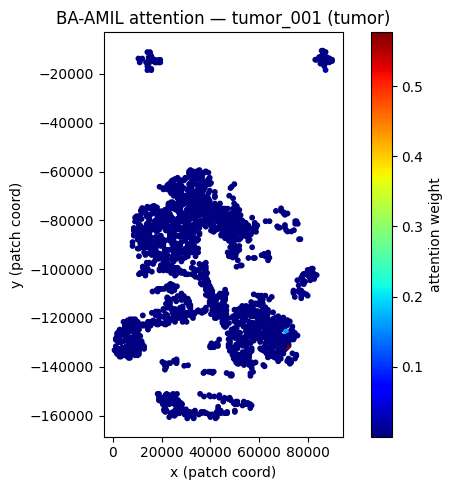

Saved to drive.
fig_attention_heatmap.png was saved


In [16]:
# %% Attention heatmap (paper Fig. 5 — representative tumor slide)
import matplotlib.pyplot as plt
import numpy as np, random

# 1) Train a short BA-AMIL on all training slides (to obtain attention)
set_seed(0)
model = build_model("BA_AMIL", CONFIG).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
train_recs = slides.to_dict("records")
for ep in range(20):
    random.shuffle(train_recs)
    run_epoch(model, train_recs, CONFIG, train=True, optimizer=opt)
print("heatmap model trained")

# 2) Select a tumor slide, get attention per patch
tumor_recs = slides[slides.label == 1].to_dict("records")
rec = tumor_recs[0]
feats, coords, nbr = load_slide(rec, CONFIG["knn_k"], CONFIG["max_patches"], seed=0)
model.eval()
with torch.no_grad():
    out = model(feats.to(DEVICE), nbr=nbr.to(DEVICE), label=rec["label"])
attn   = out["attn"].detach().cpu().numpy().ravel()
coords = (coords.numpy() if hasattr(coords, "numpy") else np.asarray(coords)).astype(float)

# 3) Color code patch coordinates by attention (spatial heatmap)
plt.figure(figsize=(6, 5))
sc = plt.scatter(coords[:, 0], -coords[:, 1], c=attn, cmap="jet", s=10)
plt.colorbar(sc, label="attention weight")
plt.title(f"BA-AMIL attention — {rec['name']} (tumor)")
plt.xlabel("x (patch coord)"); plt.ylabel("y (patch coord)")
plt.gca().set_aspect("equal"); plt.tight_layout()
plt.savefig("/content/results/fig_attention_heatmap.png", dpi=150)
plt.show()

# 4) Copy to Drive (if DRIVE_OUT is defined)
try:
    import shutil; shutil.copy("/content/results/fig_attention_heatmap.png", DRIVE_OUT)
    print("Saved to drive.")
except Exception as e:
    print("(Skipped drive copy)", e)
print("fig_attention_heatmap.png was saved")